In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

df = pd.read_parquet("../data/processed/churn_clean.parquet")

X = df.drop(columns=["churn", "churn_flag", "customerid"])
y = df["churn_flag"]

num_cols = ["tenure", "monthlycharges", "totalcharges"]
cat_cols = [c for c in X.columns if c not in num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

log_model = LogisticRegression(max_iter=5000, solver="lbfgs")
log_clf = Pipeline(steps=[("preprocess", preprocess), ("model", log_model)])
log_clf.fit(X_train, y_train)
log_proba = log_clf.predict_proba(X_test)[:, 1]
log_auc = roc_auc_score(y_test, log_proba)

rf_model = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_clf = Pipeline(steps=[("preprocess", preprocess), ("model", rf_model)])
rf_clf.fit(X_train, y_train)
rf_proba = rf_clf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)

print("Logistic AUC =", log_auc)
print("RandomForest AUC =", rf_auc)

def lift_table(y_true, proba, n_bins=10):
    tmp = pd.DataFrame({"y": y_true.values, "proba": proba})
    tmp["decile"] = pd.qcut(tmp["proba"], q=n_bins, labels=False, duplicates="drop")
    tmp["decile"] = tmp["decile"].max() - tmp["decile"]

    base_rate = tmp["y"].mean()

    agg = (tmp.groupby("decile")
           .agg(customers=("y", "size"),
                churners=("y", "sum"),
                churn_rate=("y", "mean"),
                avg_proba=("proba", "mean"))
           .reset_index()
           .sort_values("decile"))

    agg["lift"] = agg["churn_rate"] / base_rate
    return agg, base_rate

log_lift, base_rate = lift_table(y_test, log_proba, n_bins=10)
rf_lift, _ = lift_table(y_test, rf_proba, n_bins=10)

print("Base churn rate in test =", base_rate)

log_lift


Logistic AUC = 0.8420548192926709
RandomForest AUC = 0.8224004753416518
Base churn rate in test = 0.2654364797728886


,decile,customers,churners,churn_rate,avg_proba,lift
0,0,141,104,0.737589,0.726273,2.778777
1,1,141,82,0.581560,0.594662,2.190958
2,2,141,57,0.404255,0.473898,1.522983
3,3,141,48,0.340426,0.344904,1.282512
4,4,140,35,0.250000,0.232398,0.941845
5,5,141,23,0.163121,0.152006,0.614537
6,6,141,16,0.113475,0.085358,0.427504
7,7,141,5,0.035461,0.044145,0.133595
8,8,141,2,0.014184,0.019094,0.053438
9,9,141,2,0.014184,0.005064,0.053438


In [2]:
rf_lift


,decile,customers,churners,churn_rate,avg_proba,lift
0,0,141,107,0.758865,0.823023,2.858934
1,1,140,68,0.485714,0.596414,1.829870
2,2,140,62,0.442857,0.439655,1.668411
3,3,139,48,0.345324,0.313217,1.300966
4,4,144,36,0.250000,0.220334,0.941845
5,5,133,17,0.127820,0.144100,0.481545
6,6,148,19,0.128378,0.085578,0.483650
7,7,140,10,0.071429,0.040573,0.269099
8,8,127,5,0.039370,0.014048,0.148322
9,9,157,2,0.012739,0.001799,0.047992


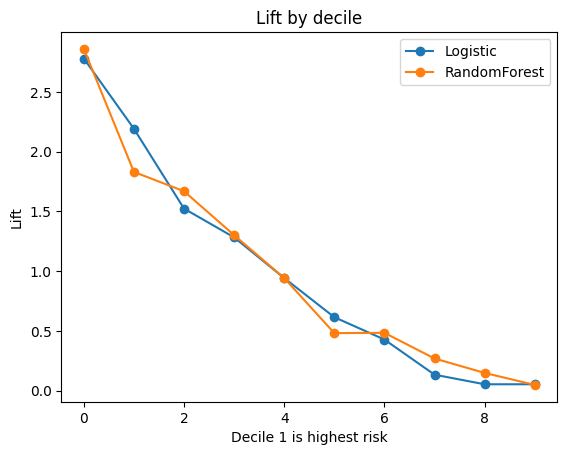

In [3]:
plt.figure()
plt.plot(log_lift["decile"], log_lift["lift"], marker="o", label="Logistic")
plt.plot(rf_lift["decile"], rf_lift["lift"], marker="o", label="RandomForest")
plt.title("Lift by decile")
plt.xlabel("Decile 1 is highest risk")
plt.ylabel("Lift")
plt.legend()
plt.show()
